To run: 

save most recent BIOGRID-ORGANISM release in tab3.zip format to data/

ensure BIOGRID_FILEPATH is correct

In [ ]:
import pandas as pd
import numpy as np
import os
from pybiomart import Server
import zipfile


BIOGRID_FILEPATH = '../data/BIOGRID-ORGANISM-5.0.257.tab3.zip'

In [37]:
# loads organism-specific BioGRID file
def load_biogrid(organism, biogrid_filepath = BIOGRID_FILEPATH):

    base = os.path.basename(biogrid_filepath) 
    organism_filename = base.replace("ORGANISM", f"ORGANISM-{organism}").replace(".zip", ".txt")

    with zipfile.ZipFile(biogrid_filepath) as z:
        with z.open(organism_filename) as f:
            return pd.read_csv(f, sep='\t', low_memory=False)
        
biogrid_human = load_biogrid('Homo_sapiens')
print(f"Human PPI data shape: {biogrid_human.shape}")

biogrid_mouse = load_biogrid('Mus_musculus')
print(f"Mouse PPI data shape: {biogrid_mouse.shape}")

biogrid_yeast = load_biogrid('Saccharomyces_cerevisiae_S288c')
print(f"Yeast PPI data shape: {biogrid_yeast.shape}")

biogrid_fly = load_biogrid('Drosophila_melanogaster')
print(f"Fly PPI data shape: {biogrid_fly.shape}")

Human PPI data shape: (1371591, 37)
Mouse PPI data shape: (109118, 37)
Yeast PPI data shape: (869229, 37)
Fly PPI data shape: (97800, 37)


In [29]:
# use BioMart to do gene mapping. Only needs to be done once. results saved to data/homolog_mapping.csv

# get homolog mapping from human to several other species, save as csv
def map_homologs():

    server = Server(host="http://www.ensembl.org")
    dataset = server.marts["ENSEMBL_MART_ENSEMBL"].datasets["hsapiens_gene_ensembl"]

    mapping = dataset.query(
        attributes=[
            "external_gene_name",
            "mmusculus_homolog_associated_gene_name",
            "scerevisiae_homolog_associated_gene_name",
            "dmelanogaster_homolog_associated_gene_name",
        ]
    )

    mapping.to_csv("../data/homolog_mapping.csv", index=False)

# map_homologs()

In [38]:
human_AD_genes = pd.read_csv("../data/DiseaseAssociatedGenes/Alzheimers_disgenet.tsv", sep="\t")["Gene"].to_list()
human_PD_genes = pd.read_csv("../data/DiseaseAssociatedGenes/Parkinsons_disgenet.tsv", sep="\t")["Gene"].to_list()
human_COVID_genes = pd.read_csv("../data/DiseaseAssociatedGenes/COVID19_disgenet.tsv", sep="\t")["Gene"].to_list()
human_BC_genes = pd.read_csv("../data/DiseaseAssociatedGenes/BreastCancer_disgenet.tsv", sep="\t")["Gene"].to_list()

In [39]:
mapping = pd.read_csv("../data/homolog_mapping.csv")

# given list of human genes, get list of homologs from a species in the mapping df
def get_homologs(human_genes, mapping, species_col):
    """
    human_genes: list of human gene names
    mapping: BioMart DataFrame
    species_col: e.g. "Mouse gene name" or "Yeast gene name"
    """
    mask = mapping["Gene name"].str.upper().isin(
        [g.upper() for g in human_genes]
    )
    result = mapping[mask][species_col].drop_duplicates().dropna().tolist()
    # result = result[result[species_col] != ""]  # drop empty homologs
    return result

diseases = {
    "AD": human_AD_genes,
    "PD": human_PD_genes,
    "COVID": human_COVID_genes,
    "BC": human_BC_genes,
}

species_cols = {
    "human": "Gene name",
    "mouse": "Mouse gene name",
    "yeast": "Saccharomyces cerevisiae gene name",
    "fly": "Drosophila melanogaster - (Fruit fly) gene name",
}

# populate dictionary of disease-associated gene lists by organism
disease_genes = {}
for disease, gene_list in diseases.items():
    disease_genes[disease] = {}
    for species, col in species_cols.items():
        disease_genes[disease][species] = get_homologs(gene_list, mapping, col)


In [40]:
# get network of disease-associated genes, QC
def filter_ppi_by_disease(ppi_df, gene_list, min_sources):

    ppi_df = ppi_df[ppi_df["Official Symbol Interactor A"].isin(gene_list) | ppi_df["Official Symbol Interactor B"].isin(gene_list)]
    print(f"Num interactions with at least one gene associated with disease: {len(ppi_df)}")

    # filter for physical interactions
    ppi_df = ppi_df[ppi_df["Experimental System Type"] == 'physical']
    print(f"After filtering for physical interactions: {len(ppi_df)}")

    # remove self interactions
    ppi_df = ppi_df[ppi_df["Official Symbol Interactor A"] != ppi_df["Official Symbol Interactor B"]]
    print(f"After removing self-interactions: {len(ppi_df)}")

    # filter for interactions with multiple studies
    ppi_df["Interactor A"] = ppi_df.apply(lambda r: sorted([r["Official Symbol Interactor A"], 
                                                    r["Official Symbol Interactor B"]])[0], axis=1)
    ppi_df["Interactor B"] = ppi_df.apply(lambda r: sorted([r["Official Symbol Interactor A"], 
                                                    r["Official Symbol Interactor B"]])[1], axis=1)

    grouped = ppi_df.groupby(["Interactor A", "Interactor B"]).size().reset_index(name="num_sources")
    print(f"After collapsing duplicates: {len(grouped)}")
    grouped = grouped[grouped["num_sources"] >= min_sources]
    print(f"After filtering for minimum {min_sources} sources: {len(grouped)}\n")

    return grouped


In [44]:
# call filter_ppi_by_disease to populate dictionary of PPI networks

biogrid = {
    "human": biogrid_human,
    "mouse": biogrid_mouse,
    "yeast": biogrid_yeast,
    "fly": biogrid_fly,
}

min_sources = {
    "human": 2,
    "mouse": 1,
    "yeast": 1,
    "fly": 1,
}

ppi = {}
for disease, species_genes in disease_genes.items():
    ppi[disease] = {}
    for species, genes in species_genes.items():
        print(f"Filtering PPI Table for {disease}-associated genes in {species}")
        ppi[disease][species] = filter_ppi_by_disease(biogrid[species], genes, min_sources[species])

Filtering PPI Table for AD-associated genes in human
Num interactions with at least one gene associated with disease: 61480
After filtering for physical interactions: 60546
After removing self-interactions: 60235
After collapsing duplicates: 45057
After filtering for minimum 2 sources: 7594

Filtering PPI Table for AD-associated genes in mouse
Num interactions with at least one gene associated with disease: 5814
After filtering for physical interactions: 5788
After removing self-interactions: 5749
After collapsing duplicates: 4962
After filtering for minimum 1 sources: 4962

Filtering PPI Table for AD-associated genes in yeast
Num interactions with at least one gene associated with disease: 18783
After filtering for physical interactions: 6329
After removing self-interactions: 6270
After collapsing duplicates: 4691
After filtering for minimum 1 sources: 4691

Filtering PPI Table for AD-associated genes in fly
Num interactions with at least one gene associated with disease: 3061
After f

In [45]:
import networkx as nx

def build_network(ppi_df):
    G = nx.Graph()
    for _, row in ppi_df.iterrows():
        G.add_edge(row["Interactor A"], row["Interactor B"])
    return G

def get_hub_genes(G, top_n=10):
    degrees = dict(G.degree())
    sorted_genes = sorted(degrees, key=degrees.get, reverse=True)
    return [(gene, degrees[gene]) for gene in sorted_genes[:top_n]]

networks = {}
hubs = {}

# find hub genes
for disease, species_ppi in ppi.items():
    networks[disease] = {}
    hubs[disease] = {}
    for species, ppi_df in species_ppi.items():
        G = build_network(ppi_df)
        networks[disease][species] = G
        hubs[disease][species] = get_hub_genes(G)
        
        degrees = [d for _, d in G.degree()]
        print(f"\n{disease} - {species}")
        print(f"  Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
        print(f"  Avg degree: {sum(degrees)/len(degrees):.2f}")
        print(f"  Top hubs: {hubs[disease][species][:5]}")


AD - human
  Nodes: 4310, Edges: 7594
  Avg degree: 3.52
  Top hubs: [('ESR1', 524), ('APP', 412), ('VCP', 374), ('HSPA1A', 337), ('PARP1', 308)]

AD - mouse
  Nodes: 3237, Edges: 4962
  Avg degree: 3.07
  Top hubs: [('Bin1', 1098), ('Mapt', 329), ('Adam10', 202), ('Kcnma1', 185), ('App', 178)]

AD - yeast
  Nodes: 1818, Edges: 4691
  Avg degree: 5.16
  Top hubs: [('XRN1', 336), ('RVS167', 251), ('ENO2', 232), ('TDH3', 220), ('SSE1', 219)]

AD - fly
  Nodes: 1380, Edges: 1900
  Avg degree: 2.75
  Top hubs: [('sgg', 150), ('TER94', 108), ('Eno', 95), ('EcR', 88), ('Uch', 68)]

PD - human
  Nodes: 3168, Edges: 5562
  Avg degree: 3.51
  Top hubs: [('HSPA8', 582), ('HSPA1A', 337), ('PARP1', 308), ('AKT1', 227), ('SNCA', 221)]

PD - mouse
  Nodes: 2174, Edges: 3660
  Avg degree: 3.37
  Top hubs: [('Htt', 735), ('Mapt', 329), ('Hspa8', 183), ('Cntnap2', 147), ('Rpl6', 139)]

PD - yeast
  Nodes: 2193, Edges: 5103
  Avg degree: 4.65
  Top hubs: [('RPS8A', 639), ('SSC1', 625), ('ENO2', 232), (

In [48]:
import pickle
with open("../data/ppi.pkl", "wb") as f:
    pickle.dump(ppi, f)
with open("../data/biogrid.pkl", "wb") as f:
    pickle.dump(biogrid, f)

TypeError: 'ECDFResult' object is not callable

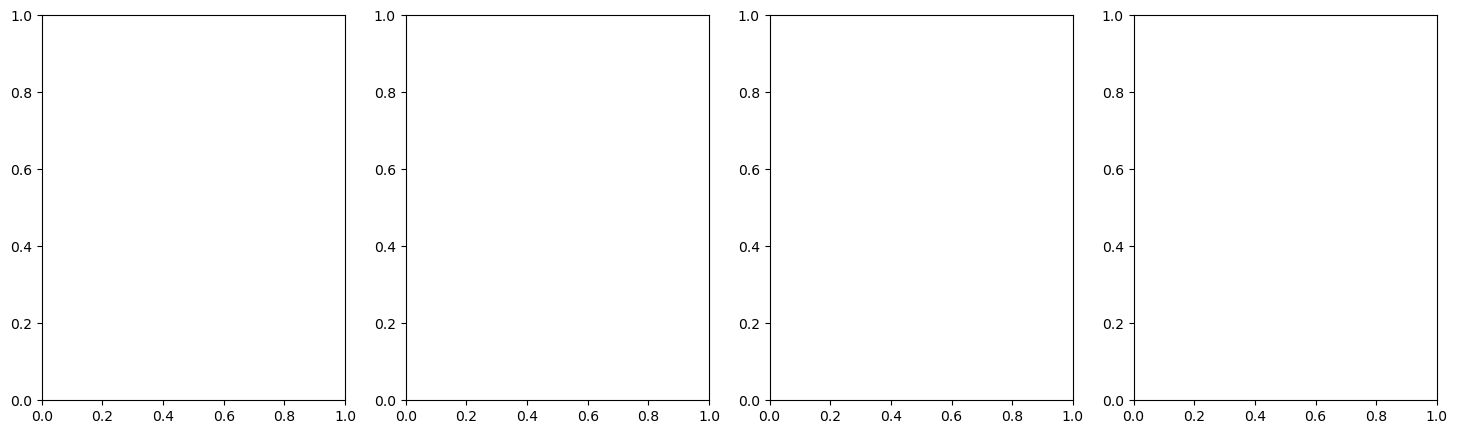

In [ ]:
import matplotlib.pyplot as plt

# TODO: improve these plots

fig, axes = plt.subplots(1, len(networks), figsize=(18, 5))

for i, (disease, species_nets) in enumerate(networks.items()):
    ax = axes[i]

    for species, G in species_nets.items():
        degrees = np.array([d for _, d in G.degree()])
        
        ecdf = ECDF(degrees)
        x = np.logspace(np.log10(1), np.log10(max(degrees)), 500)
        ax.plot(x, ecdf(x), label=species)

    ax.set_xscale("log")
    ax.set_title(disease)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Cumulative Density")
    ax.legend()

plt.tight_layout()
plt.show()

In [78]:
ppi["COVID"]["yeast"]


,Interactor A,Interactor B,num_sources
0,AKR1,NEO1,2
1,ATG23,NEO1,1
2,ATG27,NEO1,1
3,ATG8,NEO1,1
4,ATG9,NEO1,1
5,CCR4,NEO1,1
6,CSC1,NEO1,1
7,DHH1,NEO1,1
8,DOP1,NEO1,1
9,ELO1,NEO1,1
